# Plan-and-Execute

이 튜토리얼에서는 "plan-and-execute" 스타일의 에이전트를 만드는 방법을 소개하고, 이를 [LangGraph](https://langchain-ai.github.io/langgraph/)를 활용하여 구현하는 과정을 단계별로 설명합니다.  
"plan-and-execute" 전략은 복잡한 작업을 수행할 때 장기적인 계획을 먼저 수립한 뒤, 해당 계획을 단계별로 실행하며 필요에 따라 다시 계획을 재수정하는 접근법입니다.

![](./assets/langgraph-plan-and-execute.png)

---

## Plan-and-Execute란 무엇인가?

"plan-and-execute"는 다음과 같은 특징을 갖는 접근 방식입니다.

- **장기 계획 수립**: 복잡한 작업을 수행하기 전에 큰 그림을 그리는 장기 계획을 수립합니다.
- **단계별 실행 및 재계획**: 세운 계획을 단계별로 실행하고, 각 단계가 완료될 때마다 계획이 여전히 유효한지 검토한 뒤 수정할 수 있습니다.
  
이 방식은 [Plan-and-Solve 논문](https://arxiv.org/abs/2305.04091)과 [Baby-AGI 프로젝트](https://github.com/yoheinakajima/babyagi)에서 영감을 받았습니다. 전통적인 [ReAct 스타일](https://arxiv.org/abs/2210.03629)의 에이전트는 한 번에 한 단계씩 생각하는 반면, "plan-and-execute"는 명시적이고 장기적인 계획을 강조합니다.

**장점**:
1. **명시적인 장기 계획**: 강력한 LLM조차도 한 번에 장기 계획을 처리하는 데 어려움을 겪을 수 있습니다. 명시적으로 장기 계획을 수립함으로써, 보다 안정적인 진행이 가능합니다.
2. **효율적인 모델 사용**: 계획 단계에서는 더 큰/강력한 모델을 사용하고, 실행 단계에서는 상대적으로 작은/약한 모델을 사용함으로써 자원 소비를 최적화할 수 있습니다.

---

**주요 내용**

- **도구 정의**: 사용할 도구 정의
- **실행 에이전트 정의**: 실제 작업을 실행하는 에이전트 생성
- **상태 정의**: 에이전트의 상태 정의
- **계획 단계**: 장기 계획을 세우는 단계 생성
- **재계획 단계**: 작업 진행 상황에 따라 계획을 재수정하는 단계 생성
- **그래프 생성 및 실행**: 이러한 단계들을 연결하는 그래프 생성 및 실행

---

**참고**

- [LangGraph 공식 문서](https://langchain-ai.github.io/langgraph/)  
- [Plan-and-Solve 논문](https://arxiv.org/abs/2305.04091)  
- [Baby-AGI 프로젝트](https://github.com/yoheinakajima/babyagi)  
- [ReAct 논문](https://arxiv.org/abs/2210.03629)

지금부터는 각 단계를 따라가며 "plan-and-execute" 에이전트를 LangGraph로 구현하는 방법을 자세히 알아보겠습니다.

## 환경 설정

In [22]:
# API 키를 환경변수로 관리하기 위한 설정 파일
from dotenv import load_dotenv

# API 키 정보 로드
load_dotenv()

True

실습에 활용할 모델명 정의

In [23]:
from langchain_teddynote.models import get_model_name, LLMs

# 모델명 정의 - GPT4o로 수정하고 토큰 제한을 피하기 위해 더 작은 모델 사용
MODEL_NAME = "gpt-4o-mini"  # 토큰 제한이 더 관대한 모델 사용
print(MODEL_NAME)

gpt-4o-mini


## 도구 정의

사용할 도구를 먼저 정의합니다. 이 간단한 예제에서는 `Tavily`를 통해 제공되는 내장 검색 도구를 사용할 것입니다. 그러나 직접 도구를 만드는 것도 매우 쉽습니다. 

자세한 내용은 [도구(Tools)](https://wikidocs.net/262582) 문서를 참조하십시오.

In [24]:
from langchain_teddynote.tools import TavilySearch

# Tavily 검색 도구 초기화
tools = [TavilySearch(max_results=3)]

## 작업 실행 에이전트 정의

이제 작업을 실행할 `execution agent`를 생성합니다. 

이 예제에서는 각 작업에 동일한 `execution agent`를 사용할 예정이지만, 반드시 이렇게 해야 하는 것은 아닙니다.

In [25]:
from langchain_openai import ChatOpenAI
from langgraph.prebuilt import create_react_agent
from langchain_core.prompts import ChatPromptTemplate

# 프롬프트 정의
prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a helpful assistant. Answer in Korean.",
        ),
        ("human", "{messages}"),
    ]
)


# LLM 정의
llm = ChatOpenAI(model=MODEL_NAME, temperature=0)

# ReAct 에이전트 생성
agent_executor = create_react_agent(llm, tools, state_modifier=prompt)

In [26]:
# 에이전트 실행
agent_executor.invoke(
    {"messages": [("user", "랭체인 한국어 튜토리얼에 대해서 설명해줘")]}
)

{'messages': [HumanMessage(content='랭체인 한국어 튜토리얼에 대해서 설명해줘', additional_kwargs={}, response_metadata={}, id='31169d79-7dc7-4485-86a0-619bba46c790'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_yr8ob61GhJszNYPB1JtxztUb', 'function': {'arguments': '{"query":"랭체인 한국어 튜토리얼"}', 'name': 'tavily_web_search'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 107, 'total_tokens': 134, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_34a54ae93c', 'id': 'chatcmpl-C0fVK1xj5CEfLQsPqUUXftbN8vwUN', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--a88a6583-b464-4ec7-81e7-32069c1c3b7a-0', tool_calls=[{'name': 'tavily_web_search', 'args': {'query': '랭체인 한

## 상태 정의

- `input`: 사용자의 입력
- `plan`: 현재 계획
- `past_steps`: 이전에 실행한 계획과 실행 결과
- `response`: 최종 응답

In [27]:
import operator
from typing import Annotated, List, Tuple
from typing_extensions import TypedDict


# 상태 정의
class PlanExecute(TypedDict):
    input: Annotated[str, "User's input"]
    plan: Annotated[List[str], "Current plan"]
    past_steps: Annotated[List[Tuple], operator.add]
    response: Annotated[str, "Final response"]

## 계획(Plan) 단계

이제 **계획 단계**를 생성하는 방법을 고려해 보겠습니다. 이 단계에서는 `function calling` 을 사용하여 계획을 수립합니다.

In [28]:
from pydantic import BaseModel, Field
from typing import List


# Plan 모델 정의
class Plan(BaseModel):
    """Sorted steps to execute the plan"""

    steps: Annotated[List[str], "Different steps to follow, should be in sorted order"]

In [29]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI

# 계획 수립을 위한 프롬프트 템플릿 생성
planner_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """For the given objective, come up with a simple step by step plan. \
This plan should involve individual tasks, that if executed correctly will yield the correct answer. Do not add any superfluous steps. \
The result of the final step should be the final answer. Make sure that each step has all the information needed - do not skip steps.
Answer in Korean.""",
        ),
        ("placeholder", "{messages}"),
    ]
)

planner = planner_prompt | ChatOpenAI(
    model=MODEL_NAME, temperature=0
).with_structured_output(Plan)

`planner` 를 실행하여 계획을 수립한 결과를 확인합니다.

In [30]:
# Planner 실행
planner.invoke(
    {
        "messages": [
            (
                "user",
                "LangGraph 의 핵심 장단점과 LangGraph 를 사용하는 이유는 무엇인가?",
            )
        ]
    }
)

Plan(steps=['LangGraph의 정의와 기능을 이해한다.', 'LangGraph의 주요 장점을 나열한다.', 'LangGraph의 주요 단점을 나열한다.', 'LangGraph를 사용하는 이유를 정리한다.', '각 장단점과 사용 이유를 요약하여 정리한다.'])

## 재계획(Re-Plan) 단계

이제 이전 단계의 결과를 바탕으로 계획을 다시 수립하는 단계를 생성합니다.

In [31]:
from typing import Union


class Response(BaseModel):
    """Response to user."""

    # 사용자 응답
    response: str


class Act(BaseModel):
    """Action to perform."""

    # 수행할 작업: "Response", "Plan". 사용자에게 응답할 경우 Response 사용, 추가 도구 사용이 필요할 경우 Plan 사용
    action: Union[Response, Plan] = Field(
        description="Action to perform. If you want to respond to user, use Response. "
        "If you need to further use tools to get the answer, use Plan."
    )


# 계획을 재수립하기 위한 프롬프트 정의
replanner_prompt = ChatPromptTemplate.from_template(
    """For the given objective, come up with a simple step by step plan. \
This plan should involve individual tasks, that if executed correctly will yield the correct answer. Do not add any superfluous steps. \
The result of the final step should be the final answer. Make sure that each step has all the information needed - do not skip steps.

Your objective was this:
{input}

Your original plan was this:
{plan}

You have currently done the follow steps:
{past_steps}

Update your plan accordingly. If no more steps are needed and you can return to the user, then respond with that. Otherwise, fill out the plan. Only add steps to the plan that still NEED to be done. Do not return previously done steps as part of the plan.

Answer in Korean."""
)


# Replanner 생성
replanner = replanner_prompt | ChatOpenAI(
    model=MODEL_NAME, temperature=0
).with_structured_output(Act)

## 그래프 생성

이제 그래프를 생성할 수 있습니다.

In [32]:
from langchain_core.output_parsers import StrOutputParser


# 사용자 입력을 기반으로 계획을 생성하고 반환
def plan_step(state: PlanExecute):
    plan = planner.invoke({"messages": [("user", state["input"])]})
    # 생성된 계획의 단계 리스트 반환
    return {"plan": plan.steps}


# 에이전트 실행기를 사용하여 주어진 작업을 수행하고 결과를 반환
def execute_step(state: PlanExecute):
    plan = state["plan"]
    # 계획을 문자열로 변환하여 각 단계에 번호를 매김
    plan_str = "\n".join(f"{i+1}. {step}" for i, step in enumerate(plan))
    task = plan[0]
    # 현재 실행할 작업을 포맷팅하여 에이전트에 전달
    task_formatted = f"""For the following plan:
{plan_str}\n\nYou are tasked with executing [step 1. {task}]."""
    # 에이전트 실행기를 통해 작업 수행 및 결과 수신
    agent_response = agent_executor.invoke({"messages": [("user", task_formatted)]})
    # 이전 단계와 그 결과를 포함하는 딕셔너리 반환
    return {
        "past_steps": [(task, agent_response["messages"][-1].content)],
    }


# 이전 단계의 결과를 바탕으로 계획을 업데이트하거나 최종 응답을 반환
def replan_step(state: PlanExecute):
    output = replanner.invoke(state)
    # 응답이 사용자에게 반환될 경우
    if isinstance(output.action, Response):
        return {"response": output.action.response}
    # 추가 단계가 필요할 경우 계획의 단계 리스트 반환
    else:
        next_plan = output.action.steps
        if len(next_plan) == 0:
            return {"response": "No more steps needed."}
        else:
            return {"plan": next_plan}


# 에이전트의 실행 종료 여부를 결정하는 함수
def should_end(state: PlanExecute):
    if "response" in state and state["response"]:
        return "final_report"
    else:
        return "execute"


final_report_prompt = ChatPromptTemplate.from_template(
    """You are given the objective and the previously done steps. Your task is to generate a final report in markdown format.
Final report should be written in professional tone.

Your objective was this:

{input}

Your previously done steps(question and answer pairs):

{past_steps}

Generate a final report in markdown format. Write your response in Korean."""
)

final_report = (
    final_report_prompt
    | ChatOpenAI(model=MODEL_NAME, temperature=0)
    | StrOutputParser()
)


def generate_final_report(state: PlanExecute):
    past_steps = "\n\n".join(
        [
            f"Question: {past_step[0]}\n\nAnswer: {past_step[1]}\n\n####"
            for past_step in state["past_steps"]
        ]
    )
    response = final_report.invoke({"input": state["input"], "past_steps": past_steps})
    return {"response": response}

## 그래프 생성

이제 지금까지 정의한 노드를 연결하여 그래프를 생성합니다.

In [33]:
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver


# 그래프 생성
workflow = StateGraph(PlanExecute)

# 노드 정의
workflow.add_node("planner", plan_step)
workflow.add_node("execute", execute_step)
workflow.add_node("replan", replan_step)
workflow.add_node("final_report", generate_final_report)

# 엣지 정의
workflow.add_edge(START, "planner")
workflow.add_edge("planner", "execute")
workflow.add_edge("execute", "replan")
workflow.add_edge("final_report", END)

# 조건부 엣지: replan 후 종료 여부를 결정하는 함수 사용
workflow.add_conditional_edges(
    "replan",
    should_end,
    {"execute": "execute", "final_report": "final_report"},
)

# 그래프 컴파일
app = workflow.compile(checkpointer=MemorySaver())

그래프를 시각화 합니다.

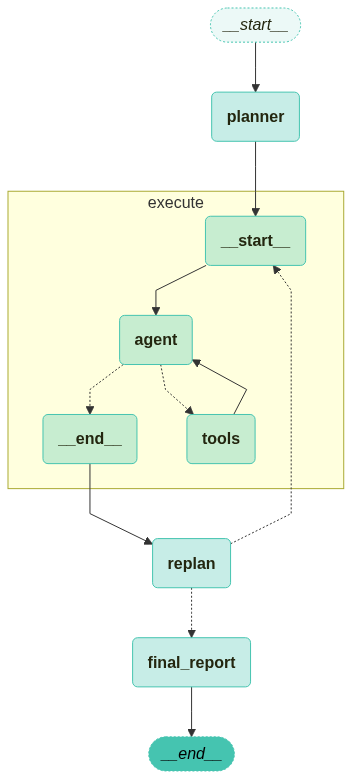

In [34]:
from langchain_teddynote.graphs import visualize_graph

visualize_graph(app, xray=True)

## 그래프 실행

In [35]:
from langchain_teddynote.messages import invoke_graph, random_uuid
from langchain_core.runnables import RunnableConfig

config = RunnableConfig(recursion_limit=50, configurable={"thread_id": random_uuid()})

inputs = {
    "input": "Modular RAG 가 기존의 Naive RAG 와 어떤 차이가 있는지와 production level 에서 사용하는 이점을 설명해줘"
}

invoke_graph(app, inputs, config)


🔄 Node: planner 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
Modular RAG의 정의와 특징을 설명한다.
Naive RAG의 정의와 특징을 설명한다.
Modular RAG와 Naive RAG의 구조적 차이를 비교한다.
Modular RAG의 장점과 이점을 나열한다.
Production level에서 Modular RAG를 사용하는 이유를 설명한다.

🔄 Node: agent in [execute] 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
================================== Ai Message ==================================
Tool Calls:
  tavily_web_search (call_KhonxN461U4Gm2Pfj0aWM2vF)
 Call ID: call_KhonxN461U4Gm2Pfj0aWM2vF
  Args:
    query: Modular RAG 정의와 특징

🔄 Node: tools in [execute] 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
================================= Tool Message =================================
Name: tavily_web_search

[{"url": "https://brunch.co.kr/@@aPda/338", "title": "12화 복잡한 RAG 분해하기-Modular RAG란? - 브런치", "content": "모듈러 RAG의 작동 원리와 장점. 모듈러 RAG는 각 모듈을 독립적으로 설계하고 이를 필요에 따라 교체하거나 결합할 수 있도록 합니다. 예를 들어", "score": 0.78054583, "raw_content": "You can make anything  \nby writing\n\nC.S.Lewis

In [36]:
snapshot = app.get_state(config).values
print(snapshot["response"])

# 최종 보고서: Modular RAG와 Naive RAG의 차이점 및 생산 수준에서의 이점

## 1. 서론

본 보고서는 Modular RAG(모듈러 검색 증강 생성)와 Naive RAG(나이브 검색 증강 생성)의 차이점과 Modular RAG가 생산 수준에서 제공하는 이점을 설명합니다. 두 접근 방식의 구조적 차이와 각 시스템의 장단점을 비교하여, Modular RAG의 혁신적인 특성을 강조합니다.

## 2. Modular RAG의 정의와 특징

### Modular RAG의 정의
Modular RAG는 검색 증강 생성 시스템을 여러 개의 독립적인 모듈로 나누어 구성하는 접근 방식입니다. 각 모듈은 특정한 역할을 담당하며, 필요에 따라 모듈을 교체하거나 조합할 수 있는 유연성을 제공합니다.

### 주요 특징
- **모듈화**: 시스템을 레고 블록처럼 구성하여 각 모듈이 독립적으로 기능합니다.
- **유연성**: 새로운 기술이나 방법론을 쉽게 적용할 수 있습니다.
- **확장성**: 다양한 작업 시나리오에 맞게 시스템을 조정할 수 있습니다.
- **유지보수 용이성**: 각 모듈이 독립적으로 유지보수됩니다.
- **동적 적응성**: 특정 작업에 맞는 모듈을 선택하여 효율적인 시스템을 구성할 수 있습니다.

## 3. Naive RAG의 정의와 특징

### Naive RAG의 정의
Naive RAG는 정보 검색과 생성 모델을 결합한 접근 방식으로, 주어진 질문에 대해 관련 정보를 검색한 후 그 정보를 바탕으로 응답을 생성합니다.

### 주요 특징
- **정보 검색**: 대량의 데이터베이스에서 관련 정보를 검색합니다.
- **생성 모델**: 검색된 정보를 바탕으로 자연어 생성 모델이 응답을 생성합니다.
- **단순한 구조**: 구현이 용이하며, 검색과 생성의 두 단계를 명확히 구분합니다.
- **제한된 컨텍스트**: 검색된 정보의 양과 질에 따라 응답의 품질이 좌우됩니다.
- **실시간 처리**: 사용자 요청에 빠르게 반응할 수 있습니다.

## 4. M

In [37]:
from IPython.display import Markdown

Markdown(snapshot["response"])

# 최종 보고서: Modular RAG와 Naive RAG의 차이점 및 생산 수준에서의 이점

## 1. 서론

본 보고서는 Modular RAG(모듈러 검색 증강 생성)와 Naive RAG(나이브 검색 증강 생성)의 차이점과 Modular RAG가 생산 수준에서 제공하는 이점을 설명합니다. 두 접근 방식의 구조적 차이와 각 시스템의 장단점을 비교하여, Modular RAG의 혁신적인 특성을 강조합니다.

## 2. Modular RAG의 정의와 특징

### Modular RAG의 정의
Modular RAG는 검색 증강 생성 시스템을 여러 개의 독립적인 모듈로 나누어 구성하는 접근 방식입니다. 각 모듈은 특정한 역할을 담당하며, 필요에 따라 모듈을 교체하거나 조합할 수 있는 유연성을 제공합니다.

### 주요 특징
- **모듈화**: 시스템을 레고 블록처럼 구성하여 각 모듈이 독립적으로 기능합니다.
- **유연성**: 새로운 기술이나 방법론을 쉽게 적용할 수 있습니다.
- **확장성**: 다양한 작업 시나리오에 맞게 시스템을 조정할 수 있습니다.
- **유지보수 용이성**: 각 모듈이 독립적으로 유지보수됩니다.
- **동적 적응성**: 특정 작업에 맞는 모듈을 선택하여 효율적인 시스템을 구성할 수 있습니다.

## 3. Naive RAG의 정의와 특징

### Naive RAG의 정의
Naive RAG는 정보 검색과 생성 모델을 결합한 접근 방식으로, 주어진 질문에 대해 관련 정보를 검색한 후 그 정보를 바탕으로 응답을 생성합니다.

### 주요 특징
- **정보 검색**: 대량의 데이터베이스에서 관련 정보를 검색합니다.
- **생성 모델**: 검색된 정보를 바탕으로 자연어 생성 모델이 응답을 생성합니다.
- **단순한 구조**: 구현이 용이하며, 검색과 생성의 두 단계를 명확히 구분합니다.
- **제한된 컨텍스트**: 검색된 정보의 양과 질에 따라 응답의 품질이 좌우됩니다.
- **실시간 처리**: 사용자 요청에 빠르게 반응할 수 있습니다.

## 4. Modular RAG와 Naive RAG의 구조적 차이

### 구조적 접근 방식
- **Naive RAG**: 데이터의 인덱싱, 검색, 생성의 세 단계를 단순하게 결합합니다.
- **Modular RAG**: 각 단계를 전문 모듈로 분리하여 독립적으로 최적화할 수 있습니다.

### 단계별 처리
- **Naive RAG**: 인덱싱, 검색, 생성의 세 단계를 간단히 처리합니다.
- **Modular RAG**: 인덱싱, 사전 검색, 검색, 후처리, 생성을 모듈화하여 정교한 접근 방식을 제공합니다.

### 유연성과 최적화
- **Naive RAG**: 단순성과 신속한 구현을 목표로 하며, 복잡한 데이터 관리가 필요하지 않습니다.
- **Modular RAG**: 각 모듈을 독립적으로 최적화할 수 있어 복잡한 AI 응용 프로그램에 적합합니다.

## 5. Modular RAG의 장점과 이점

1. **유연성**: 모듈을 쉽게 교체하거나 조합할 수 있습니다.
2. **확장성**: 새로운 기술을 빠르게 적용할 수 있습니다.
3. **복잡도 감소**: 시스템의 복잡도를 낮추고 유지 관리가 용이합니다.
4. **다양한 데이터 처리**: 다양한 형태의 데이터를 처리할 수 있습니다.
5. **재사용성**: 독립적인 모듈은 다른 시스템에서도 재사용 가능합니다.
6. **동적이고 적응 가능한 시스템**: 특정 작업에 맞는 모듈을 선택하여 효율적인 시스템을 구성할 수 있습니다.

## 6. Production Level에서 Modular RAG를 사용하는 이유

1. **유연성 및 모듈화**: 각 모듈을 독립적으로 개발하고 최적화할 수 있습니다.
2. **확장성**: 클라우드 네이티브 서비스와 컨테이너화를 활용하여 성능 저하를 방지합니다.
3. **정확성 향상**: 각 모듈이 특정 작업에 최적화되어 더 정확한 정보를 제공합니다.
4. **커스터마이징 가능성**: 도메인별 요구 사항에 맞게 모듈을 조정할 수 있습니다.
5. **효율적인 통합**: 다양한 기술 스택과의 통합이 용이합니다.
6. **지속적인 개선**: 사용자 피드백을 통해 성능을 지속적으로 개선할 수 있습니다.
7. **비용 효율성**: 리소스 사용을 최소화하여 운영 비용을 줄일 수 있습니다.

## 7. 결론

Modular RAG는 기존의 Naive RAG에 비해 유연성과 확장성을 제공하며, 복잡한 비즈니스 환경에서의 AI 시스템 구축에 있어 매우 유용한 선택입니다. Modular RAG의 구조적 차별성과 장점들은 다양한 작업 시나리오에 맞는 맞춤형 솔루션을 제공할 수 있는 가능성을 보여줍니다.

In [38]:
print(snapshot["response"])

# 최종 보고서: Modular RAG와 Naive RAG의 차이점 및 생산 수준에서의 이점

## 1. 서론

본 보고서는 Modular RAG(모듈러 검색 증강 생성)와 Naive RAG(나이브 검색 증강 생성)의 차이점과 Modular RAG가 생산 수준에서 제공하는 이점을 설명합니다. 두 접근 방식의 구조적 차이와 각 시스템의 장단점을 비교하여, Modular RAG의 혁신적인 특성을 강조합니다.

## 2. Modular RAG의 정의와 특징

### Modular RAG의 정의
Modular RAG는 검색 증강 생성 시스템을 여러 개의 독립적인 모듈로 나누어 구성하는 접근 방식입니다. 각 모듈은 특정한 역할을 담당하며, 필요에 따라 모듈을 교체하거나 조합할 수 있는 유연성을 제공합니다.

### 주요 특징
- **모듈화**: 시스템을 레고 블록처럼 구성하여 각 모듈이 독립적으로 기능합니다.
- **유연성**: 새로운 기술이나 방법론을 쉽게 적용할 수 있습니다.
- **확장성**: 다양한 작업 시나리오에 맞게 시스템을 조정할 수 있습니다.
- **유지보수 용이성**: 각 모듈이 독립적으로 유지보수됩니다.
- **동적 적응성**: 특정 작업에 맞는 모듈을 선택하여 효율적인 시스템을 구성할 수 있습니다.

## 3. Naive RAG의 정의와 특징

### Naive RAG의 정의
Naive RAG는 정보 검색과 생성 모델을 결합한 접근 방식으로, 주어진 질문에 대해 관련 정보를 검색한 후 그 정보를 바탕으로 응답을 생성합니다.

### 주요 특징
- **정보 검색**: 대량의 데이터베이스에서 관련 정보를 검색합니다.
- **생성 모델**: 검색된 정보를 바탕으로 자연어 생성 모델이 응답을 생성합니다.
- **단순한 구조**: 구현이 용이하며, 검색과 생성의 두 단계를 명확히 구분합니다.
- **제한된 컨텍스트**: 검색된 정보의 양과 질에 따라 응답의 품질이 좌우됩니다.
- **실시간 처리**: 사용자 요청에 빠르게 반응할 수 있습니다.

## 4. M